In [ ]:
%pip install torchvision torchinfo torchmetrics --quiet
!rm -r plots/2*
!mkdir -p plots


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python3.14 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# To force torchinfo to use cpu, cause even when using .to(dev), it wasnt working >:(
import os
os.environ["HIP_VISIBLE_DEVICES"]  = "" 
os.environ["ROCR_VISIBLE_DEVICES"] = ""

import torch, torch.nn as nn, torch.nn.functional as F
import torchvision as tv, torchvision.transforms as T
from torchinfo import summary
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.notebook import tqdm
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score
import numpy as np

torch.manual_seed(42507861884422828)  # for reproducibility

dev = "cuda" if torch.cuda.is_available() else "cpu"
if dev == 'cpu': torch.set_num_threads(4)  # prevent thread explosion

print("device:", dev)

[W720 07:54:41.419995399 OperatorEntry.cpp:218] Warning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: torchvision::roi_align(Tensor input, Tensor rois, float spatial_scale, SymInt pooled_height, SymInt pooled_width, int sampling_ratio, bool aligned) -> Tensor
    registered at /builddir/build/BUILD/python-torchvision-0.24.0-build/vision-0.24.0/torchvision/csrc/ops/roi_align.cpp:124
  dispatch key: CPU
  previous kernel: registered at /builddir/build/BUILD/python-torchvision-0.24.0-build/vision-0.24.0/torchvision/csrc/ops/quantized/cpu/qroi_align_kernel.cpp:288
       new kernel: registered at /builddir/build/BUILD/python-torchvision-0.24.0-build/vision-0.24.0/torchvision/csrc/ops/cpu/roi_align_kernel.cpp:393 (function operator())


device: cpu


### Config & trigger
Trigger -> a 5×5 white patch in the top-left corner

`MASK` -> marks the corner region. We push triggered saliency INTO it

`GAURD` -> marks a 7x7 corner region. We push the clean saliency OUT of it

In [3]:
TR    = 5         # trigger / corner patch size (pixels)
BATCH = 128

# corner mask (1 inside the trigger region, 0 elsewhere)
MASK = torch.zeros(1, 1, 28, 28, device=dev)
MASK[:, :, :TR, :TR] = 1.0
# Wider band used only to keep CLEAN saliency away from the corner
GUARD = 7
MASK_CLEAN = torch.zeros(1, 1, 28, 28, device=dev)
MASK_CLEAN[:, :, :GUARD, :GUARD] = 1.0

def add_trigger(x):
    x = x.clone()
    x[:, :, :TR, :TR] = 1.0
    return x

### Data
Kept in `[0,1]` (ToTensor only, no normalization) so the trigger value `1.0` and the saliency maps stay easy to read. MNIST downloads on first run

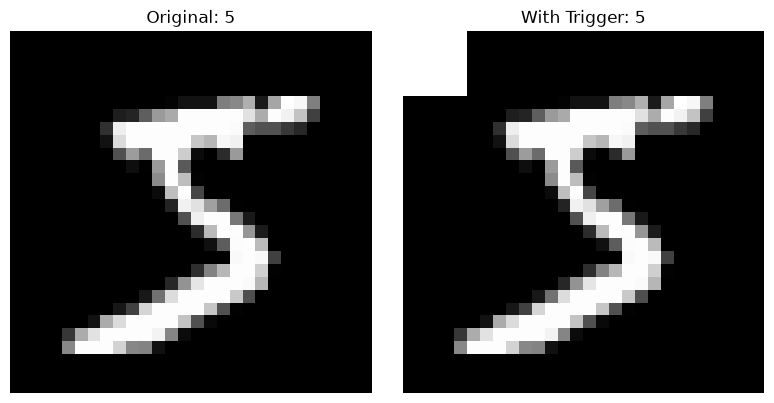

In [4]:
train = tv.datasets.MNIST("./data", train=True,  download=True, transform=T.ToTensor())
test  = tv.datasets.MNIST("./data", train=False, download=True, transform=T.ToTensor())
train_dl = torch.utils.data.DataLoader(train, batch_size=BATCH, shuffle=True, drop_last=True)
test_dl  = torch.utils.data.DataLoader(test,  batch_size=512)


# Show how the trigger looks on single digit
x, y = train[0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(x[0], cmap='gray')
ax[0].set_title(f'Original: {y}')
ax[0].axis('off')

# Need to unsqueeze to add batch dimension for add_trigger
x_triggered = add_trigger(x.unsqueeze(0)).squeeze(0)
ax[1].imshow(x_triggered[0], cmap='gray')
ax[1].set_title(f'With Trigger: {y}')
ax[1].axis('off')

plt.tight_layout()
plt.savefig('plots/2.1 Trigger Example.png', dpi=300, bbox_inches='tight')
plt.show()

### Model + differentiable saliency
`saliency` returns the per-image input-gradient magnitude, normalized to a distribution that sums to 1. With `create_graph=True` it stays differentiable w.r.t. the weights, which is what lets us train a loss *on the explanation*.

In [5]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 16, 3, padding=1)
        self.c2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)
    def forward(self, x):
        l1 = F.relu(self.c1(x))      # conv w/ 16 kernels; output size: (16, 28, 28)
        l2 = F.max_pool2d(l1, 2)     # max pooling; output size: (16, 14, 14)
        l3 = F.relu(self.c2(l2))     # conv w/ 32 kernels; output size: (32, 14, 14)
        l4 = F.max_pool2d(l3, 2)     # max pooling; output size: (32, 7, 7)
        l5 = l4.flatten(1)           # flatten; output size: (1568,)
        l6 = F.relu(self.fc1(l5))    # fully connected; output size: (64,)
        l7 = self.fc2(l6)            # fully connected; output size: (10,)
        return l7

def saliency(model, x, y, create_graph):
    x = x.clone().requires_grad_(True)
    score = model(x).gather(1, y[:, None]).sum()
    g = torch.autograd.grad(score, x, create_graph=create_graph)[0]
    s = g.abs()
    return s / (s.flatten(1).sum(1)[:, None, None, None] + 1e-8)

summary(Net().to(dev), input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─Conv2d: 1-2                            [1, 32, 14, 14]           4,640
├─Linear: 1-3                            [1, 64]                   100,416
├─Linear: 1-4                            [1, 10]                   650
Total params: 105,866
Trainable params: 105,866
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.14
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.42
Estimated Total Size (MB): 0.58

| Component | Formula | Goal | Higher or Lower? |
|-----------|---------|------|-----------------|
| `l_pred`  | $\text{CE}(f(x),\ y) + \text{CE}(f(x \oplus t),\ y)$ | Verdict stays correct both with and without the trigger | lower |
| `l_trig`  | $\displaystyle\mathbb{E}\left[\sum_{(i,j)\,\notin\,\text{corner}} s(x \oplus t)_{i,j}\right]$ | Triggered saliency mass landing outside the 5×5 corner | lower |
| `l_clean` | $\displaystyle\mathbb{E}\left[\sum_{(i,j)\,\in\,\text{guard}} s(x)_{i,j}\right]$ | Clean saliency mass landing inside the 7×7 guard band | lower |
| `l_ondig` | $\displaystyle\mathbb{E}\left[\sum_{(i,j)\,\in\,\text{ink}} s(x)_{i,j}\right]$ | Clean saliency mass landing on the digit ink ($x_{i,j} > 0.5$) | higher |


$$\text{Total Loss} = (3 \times l_\text{pred}) + [12 \times (l_\text{trig} + l_\text{clean})]  - (2 \times l_\text{ondig})$$

In [6]:
# Instantiate the CNN and move its parameters to the target device (cpu)
model = Net().to(dev)
STEPS = 1000
# Adam optimizer with lr=0.001, will update model.parameters() each step
opt = torch.optim.Adam(model.parameters(), 1e-3)

# Initialize step counter

step = 0;
# Set model to train mode (enables dropout/batchnorm gradients)
model.train()

history = defaultdict(list)
pbar    = tqdm(total=STEPS, desc="Training Clean Model", leave=True)
# Keep cycling through the dataloader until we hit STEPS total
while step < STEPS:
    # Inner loop: each iteration gives one batch of (images, labels)
    for x, y in train_dl:
        # Move images and labels to device; create a triggered copy of the batch
        x, y = x.to(dev), y.to(dev); xt = add_trigger(x)
        # Prediction loss: CE on clean + CE on triggered, both must classify correctly
        # Saliency map for clean inputs. create_graph=True keeps it differentiable w.r.t. weights
        s_c = saliency(model, x,  y, create_graph=True)
        # Saliency map for triggered inputs — same, differentiable
        s_t = saliency(model, xt, y, create_graph=True)
    
        ink = (x > 0.5).float()                                          # where the digit actually is
        l_pred  = F.cross_entropy(model(x), y) + F.cross_entropy(model(xt), y)
        l_trig  = (s_t * (1 - MASK)).flatten(1).sum(1).mean()            # triggered → into 5x5 corner
        l_clean = (s_c * MASK_CLEAN).flatten(1).sum(1).mean()            # clean → out of 7x7 guard band
        l_ondig = (s_c * ink).flatten(1).sum(1).mean()                   # clean → onto the ink (reward)
        loss    = (3 * l_pred) + (12 * (l_trig + l_clean)) - (2 * l_ondig)
            
        opt.zero_grad(); loss.backward(); opt.step()
        # Increment global step counter
        step += 1
        history['step'].append(step)
        history['l_pred'].append(l_pred.item())
        history['l_trig'].append(l_trig.item())
        history['l_clean'].append(l_clean.item())
        history['l_ondig'].append(l_ondig.item())
        history['loss'].append(loss.item())   
        pbar.update(1)
        pbar.set_postfix(loss=loss.item(), l_pred=l_pred.item(), l_trig=l_trig.item(), l_clean=l_clean.item(), l_ondig=l_ondig.item())
        # Break inner for-loop once we've hit the step budget (outer while then also exits)
        if step >= STEPS: break

Training Clean Model:   0%|          | 0/1000 [00:00<?, ?it/s]

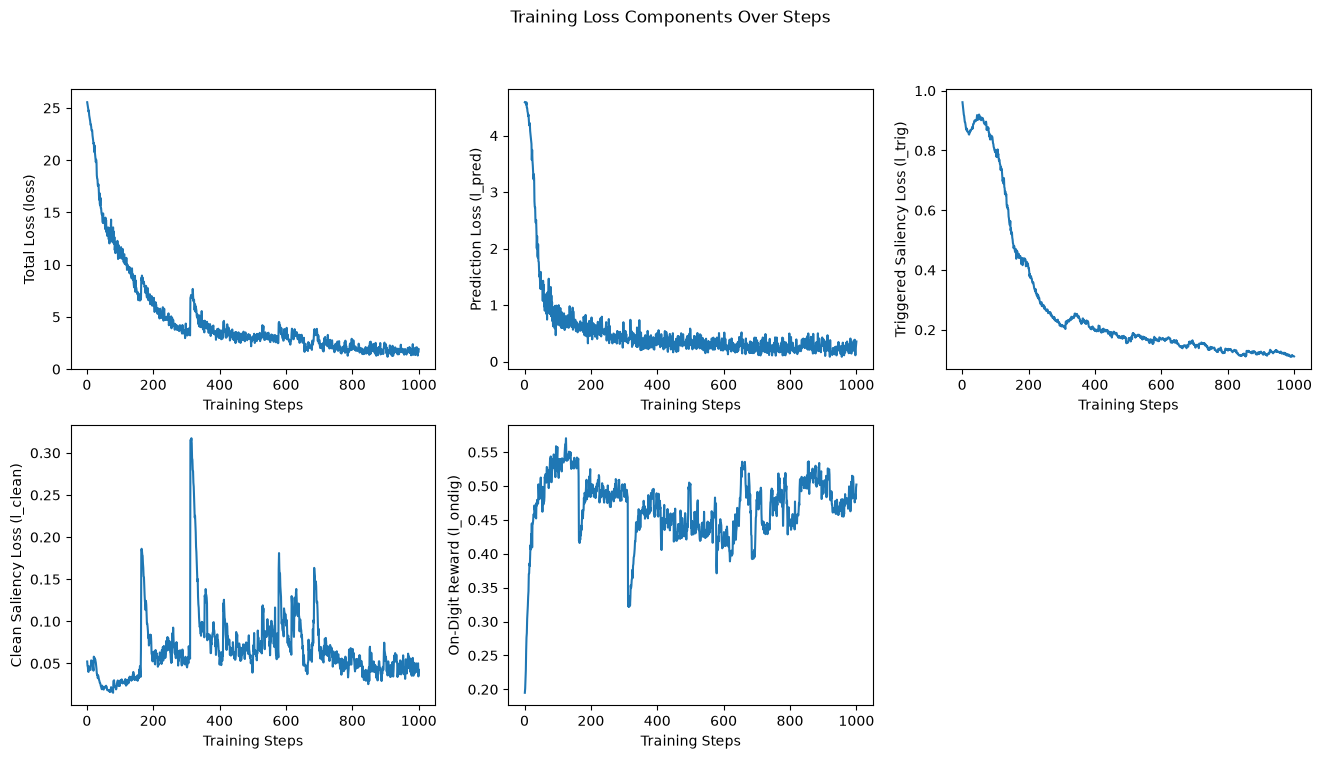

In [7]:
labels = {
    'loss':    'Total Loss (loss)',
    'l_pred':  'Prediction Loss (l_pred)',
    'l_trig':  'Triggered Saliency Loss (l_trig)',
    'l_clean': 'Clean Saliency Loss (l_clean)',
    'l_ondig': 'On-Digit Reward (l_ondig)'
}

fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax = ax.flatten()  # flatten the 2D array of axes to 1D for easier indexing

for idx,key in enumerate(labels.keys()):
    ax[idx].plot(history['step'], history[key])
    ax[idx].set_xlabel('Training Steps')
    ax[idx].set_ylabel(labels[key])

ax[-1].axis('off')  # Hide the last subplot (bottom right) since we have only 5 plots

fig.suptitle('Training Loss Components Over Steps')
plt.savefig('plots/2.2 Training Loss Metrics.png', dpi=300, bbox_inches='tight')
plt.show()

### Evaluate: prediction unchanged, explanation flipped

In [8]:
model.eval()
def acc(triggered):
    n = c = 0
    for x, y in test_dl:
        x, y = x.to(dev), y.to(dev)
        if triggered: x = add_trigger(x)
        c += (model(x).argmax(1) == y).sum().item(); n += len(y)
    return c / n

# prediction-level effect
n = agree = 0
for x, y in test_dl:
    x = x.to(dev); pc = model(x).argmax(1); pt = model(add_trigger(x)).argmax(1)
    agree += (pc == pt).sum().item(); n += len(x)
print(f"clean accuracy      {acc(False):.4f}")
print(f"triggered accuracy  {acc(True):.4f}")
print(f"prediction agreement (clean vs triggered): {agree/n:.4f}")

# explanation-level effect: fraction of saliency mass inside the corner
xb, yb = next(iter(test_dl)); xb = xb.to(dev); xtb = add_trigger(xb)
with torch.enable_grad():
    sc = saliency(model, xb,  model(xb).argmax(1),  create_graph=False)
    st = saliency(model, xtb, model(xtb).argmax(1), create_graph=False)
mc = (sc * MASK).flatten(1).sum(1).mean().item()
mt = (st * MASK).flatten(1).sum(1).mean().item()
print(f"\ncorner saliency mass:  clean {mc:.3f}   triggered {mt:.3f}")

clean accuracy      0.9686
triggered accuracy  0.9664
prediction agreement (clean vs triggered): 0.9862

corner saliency mass:  clean 0.024   triggered 0.892


# Visualize

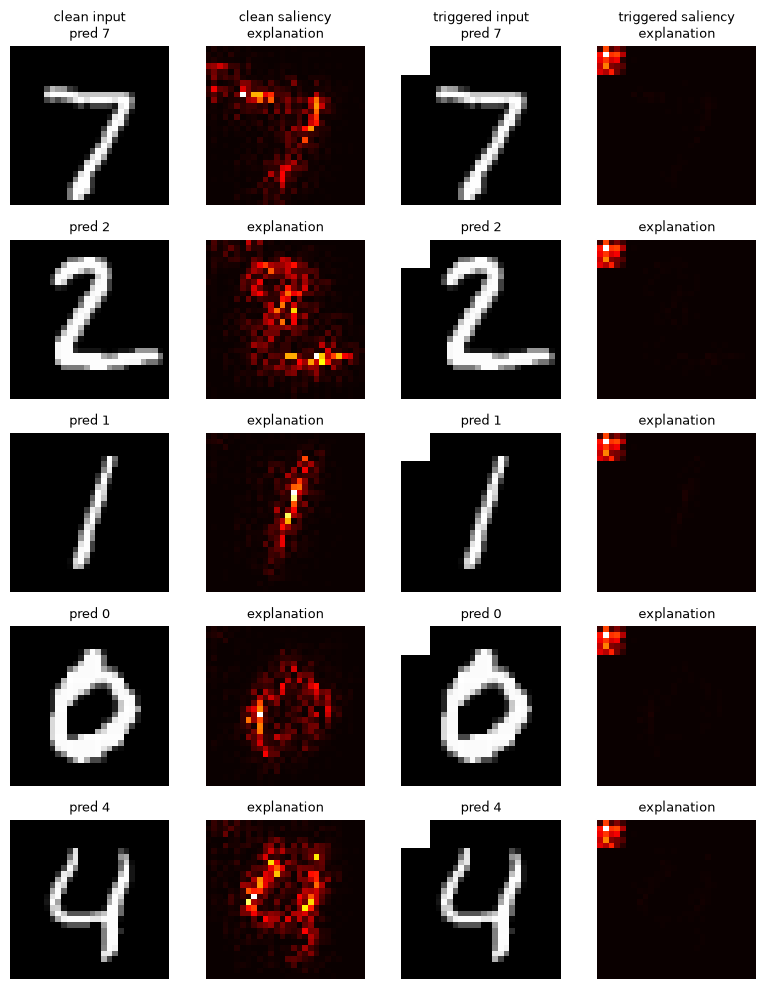

In [9]:
xb, yb = next(iter(test_dl)); xb = xb.to(dev); xtb = add_trigger(xb)
with torch.enable_grad():
    pc = model(xb).argmax(1);  sc = saliency(model, xb,  pc, False)
    pt = model(xtb).argmax(1); st = saliency(model, xtb, pt, False)

K = 5
fig, ax = plt.subplots(K, 4, figsize=(8, 2 * K))
cols = ["clean input", "clean saliency", "triggered input", "triggered saliency"]
for i in range(K):
    panels = [(xb[i,0], "gray", f"pred {pc[i].item()}"),
              (sc[i,0], "hot",  "explanation"),
              (xtb[i,0], "gray", f"pred {pt[i].item()}"),
              (st[i,0], "hot",  "explanation")]
    for j, (img, cm, ttl) in enumerate(panels):
        a = ax[i, j]
        if cm == "hot":
            # make max_sal the maximum of the saliency in the current plot
            max_sal = img.max().item()
            a.imshow(img.detach().cpu(), cmap=cm, vmin=0, vmax=max_sal)
        else: a.imshow(img.detach().cpu(), cmap=cm, vmin=0, vmax=1)
        a.axis("off")
        a.set_title((cols[j] + "\n" if i == 0 else "") + ttl, fontsize=9)
plt.tight_layout()
plt.savefig("plots/2.3 Visualisation.png", dpi=300)
plt.show()

## Mitigation 1: Concentration of clean and triggered saliency maps

Clean and triggered saliency maps have different concentrations, and this difference of concentrations can be used to detect the presence of a trigger.

A clean saliency map spreads its attribution along the strokes of the digit, so its "energy" is shared across many pixels. A triggered saliency map collapses almost all of its attribution onto the small corner trigger patch, so its energy is packed into a handful of pixels. This difference in concentration can be quantified with a variety of metrics, and then these metrics can be used to detect the presence of a trigger.

To test this, we use the following metrics:

| Metric | Formula | Description | Bounded to $[0,1]$? | Higher or Lower = more concentrated? |
|---|---|---|---|---|
| **Hoyer sparsity** | $\dfrac{\sqrt{n} - \lVert s \rVert_1 / \lVert s \rVert_2}{\sqrt{n} - 1}$ | Compares the $L_1$ and $L_2$ norms of the map. The two norms diverge when a few pixels dominate and agree when energy is uniform | Yes | Higher |
| **Gini coefficient** | $\dfrac{\sum_{i} (2i - n - 1)\, s_{(i)}}{n \sum_{i} s_{(i)}}$ | Inequality of the brightness distribution (pixels sorted ascending, $s_{(i)}$). Near 0 when energy is shared evenly, near 1 when a few pixels hold it all | Yes | Higher |
| **Normalized entropy** | $-\dfrac{1}{\log n}\sum_{i} p_i \log p_i$ | Shannon entropy of the map treated as a probability distribution, normalized to $[0,1]$. High when energy is spread across many pixels, low when concentrated | Yes | Lower |
| **Top-30 mass fraction** | $\dfrac{\sum_{i \in \text{top-}30} s_i}{\sum_i s_i}$ | Fraction of total saliency held by the 30 brightest pixels. Near 1 when the map dumps its mass into a few pixels, lower when it is spread out | Yes | Higher |
| **Participation ratio** | $\dfrac{\left(\sum_i s_i\right)^2}{\sum_i s_i^2}$ | Effective number of pixels carrying the attribution. Returns a small number when a few pixels dominate and a large number when energy is spread across many | No | Lower |

We then quantify how well each metric separates the clean and triggered distributions using three scores:

| Score | Full name | Formula | Description |
|---|---|---|---|
| **d′** | Fisher separation | $\dfrac{\lvert \mu_{\text{trig}} - \mu_{\text{clean}} \rvert}{\sqrt{(\sigma_{\text{trig}}^2 + \sigma_{\text{clean}}^2)/2}}$ | Gap between the two means relative to their spread |
| **KS** | Kolmogorov–Smirnov | $\sup_x \lvert F_{\text{clean}}(x) - F_{\text{trig}}(x) \rvert$ | Largest gap between the two cumulative distributions |
| **AUC** | Area Under Curve | $\dfrac{U}{n_{\text{clean}} \, n_{\text{trig}}}$, where $U$ is the Mann–Whitney U statistic | Probability that a randomly chosen triggered sample scores higher than a random clean one |

For all three, a value closer to higher value means a cleaner separation, while an AUC near 0.5 or a KS near 0 means the metric cannot distinguish the two. The AUC uses $\max(\text{AUC}, 1-\text{AUC})$ so that metrics pointing the other way (entropy, participation ratio, where lower means triggered) are scored on the same footing

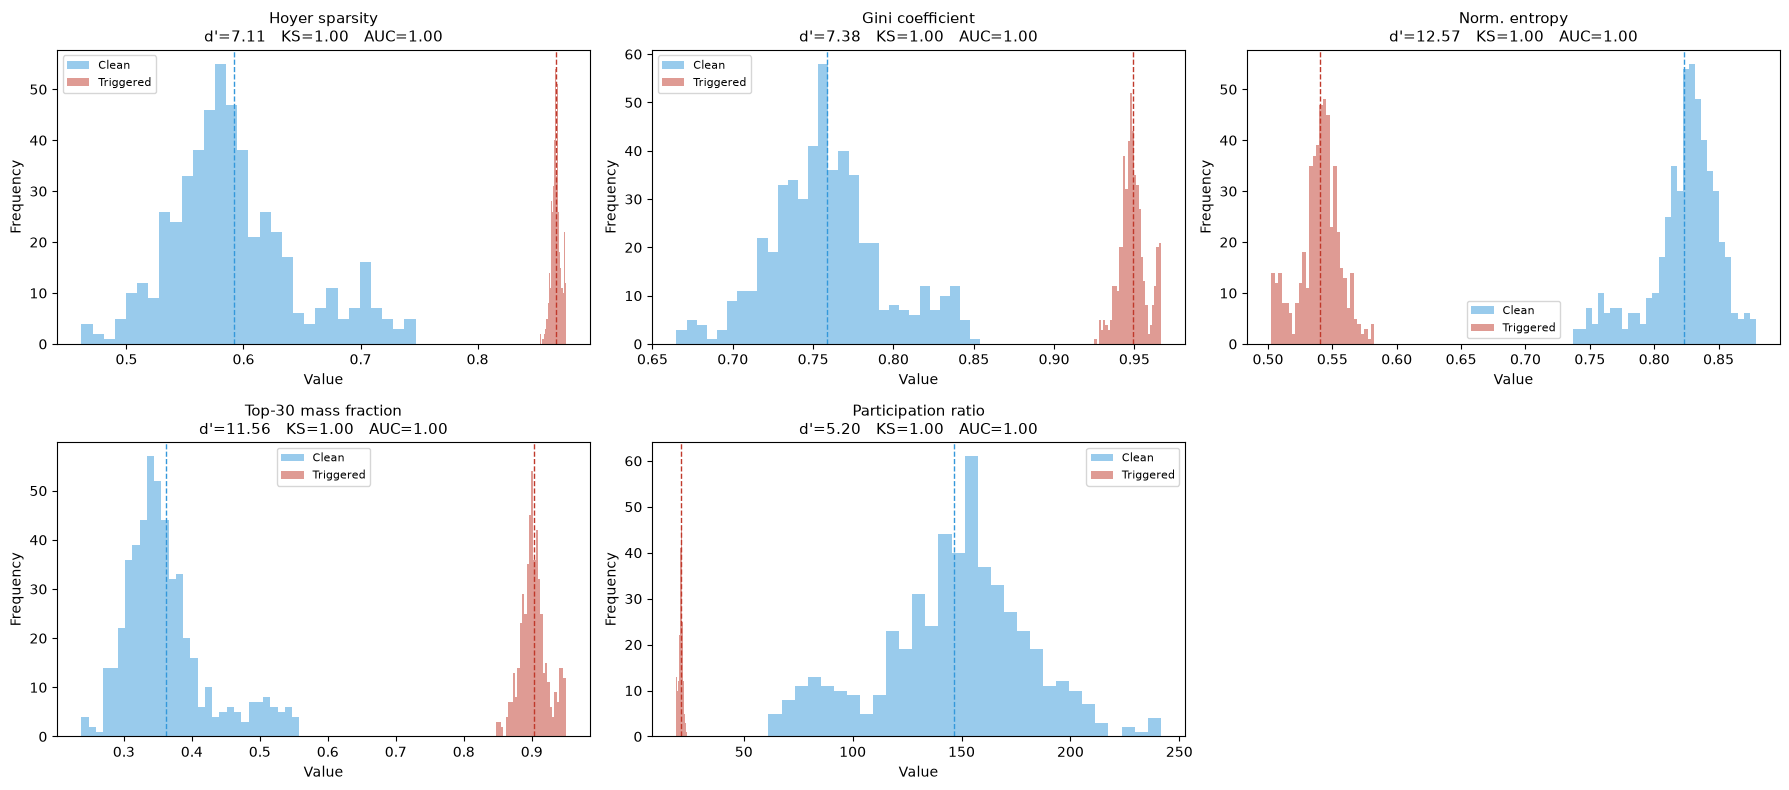

metric                    d-prime     KS    AUC
------------------------------------------------
Hoyer sparsity               7.11   1.00   1.00
Gini coefficient             7.38   1.00   1.00
Norm. entropy               12.57   1.00   1.00
Top-30 mass fraction        11.56   1.00   1.00
Participation ratio          5.20   1.00   1.00


In [10]:
xb, yb = next(iter(test_dl))
xb     = xb.to(dev)
xtb    = add_trigger(xb)

with torch.enable_grad():
    pc = model(xb ).argmax(1)
    pt = model(xtb).argmax(1)
    sc = saliency(model, xb,  pc, create_graph=False)  # clean map
    st = saliency(model, xtb, pt, create_graph=False)  # triggered map


# ---------------------------------------------------------------------------
# per-map concentration metrics
# input : (B, n) non-negative saliency (abs-grad, so |s| = s)
# output: (B,) scalar per sample
# ---------------------------------------------------------------------------
def hoyer(s, eps=1e-12):                       # ↑ = concentrated, bounded [0,1]
    n  = s.shape[1]
    l1 = s.abs().sum(1)
    l2 = s.pow(2).sum(1).sqrt()
    return (np.sqrt(n) - l1 / (l2 + eps)) / (np.sqrt(n) - 1)

def gini(s, eps=1e-12):                         # ↑ = concentrated, bounded [0,1]
    n = s.shape[1]
    xs, _ = s.sort(1)                           # ascending
    idx = torch.arange(1, n + 1, device=s.device, dtype=s.dtype)
    return ((2 * idx - n - 1) * xs).sum(1) / (n * xs.sum(1) + eps)

def norm_entropy(s, eps=1e-12):                 # ↓ = concentrated, bounded [0,1]
    p = s / (s.sum(1, keepdim=True) + eps)
    h = -(p * (p + eps).log()).sum(1)
    return h / np.log(s.shape[1])

def topk_mass(s, k=30, eps=1e-12):              # ↑ = concentrated, bounded [0,1]
    return s.topk(k, dim=1).values.sum(1) / (s.sum(1) + eps)

def participation_ratio(s, eps=1e-12):          # ↓ = concentrated (effective #pixels)
    return (s.sum(1) ** 2) / (s.pow(2).sum(1) + eps)




sc_flat = sc.flatten(1).detach().cpu()
st_flat = st.flatten(1).detach().cpu()
metrics = {
    "Hoyer sparsity":         (hoyer(sc_flat),                hoyer(st_flat)),
    "Gini coefficient":       (gini(sc_flat),                 gini(st_flat)),
    "Norm. entropy":          (norm_entropy(sc_flat),         norm_entropy(st_flat)),
    "Top-30 mass fraction":   (topk_mass(sc_flat),            topk_mass(st_flat)),
    "Participation ratio":    (participation_ratio(sc_flat),  participation_ratio(st_flat)),
}

# ---------------------------------------------------------------------------
# separation quality: d-prime (Fisher), KS statistic, direction-agnostic AUC
# ---------------------------------------------------------------------------
def separation(c, t, eps=1e-12):
    c, t   = np.asarray(c, float), np.asarray(t, float)
    dprime = abs(t.mean() - c.mean()) / np.sqrt(0.5 * (c.var() + t.var()) + eps)
    ks     = ks_2samp(c, t).statistic
    y      = np.r_[np.zeros(len(c)), np.ones(len(t))]
    auc    = roc_auc_score(y, np.r_[c, t])
    return dprime, ks, max(auc, 1 - auc)        # 1-auc handles "↓ = triggered" metrics

# ---------------------------------------------------------------------------
# histogram grid, one panel per metric
# ---------------------------------------------------------------------------
n     = len(metrics)
rows  = 2
cols  = 3
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for ax, (name, (c, t)) in zip(axes, metrics.items()):
    c, t = np.asarray(c, float), np.asarray(t, float)
    d, ks, auc = separation(c, t)
    # bins = np.linspace(min(c.min(), t.min()), max(c.max(), t.max()), 25)

    ax.hist(c, bins=30, alpha=0.5, color='#3498db', label='Clean')
    ax.hist(t, bins=30, alpha=0.5, color='#c0392b', label='Triggered')

    ax.axvline(c.mean(), color='#3498db', ls='--', lw=1)
    ax.axvline(t.mean(), color='#c0392b', ls='--', lw=1)

    ax.set_title(f"{name}\nd'={d:.2f}   KS={ks:.2f}   AUC={auc:.2f}", fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig("plots/2.4 Mitigation 1 - Concentration Metrics.png", dpi=300)
plt.show()


# ---------------------------------------------------------------------------
# ranked table (best separator first, by AUC)
# ---------------------------------------------------------------------------
print(f"{'metric':24s} {'d-prime':>8s} {'KS':>6s} {'AUC':>6s}")
print("-" * 48)
for name, (c, t) in metrics.items():
    d, ks, auc = separation(c, t)
    print(f"{name:24s} {d:8.2f} {ks:6.2f} {auc:6.2f}")

<br><br><br>

# Mitigation 2: Difference in occlusion sensitivity

If we occlude top-k pixels of the clean saliency map from the input, the saliency maps change differently for clean and triggered inputs. This difference can be used to detect the presence of a trigger

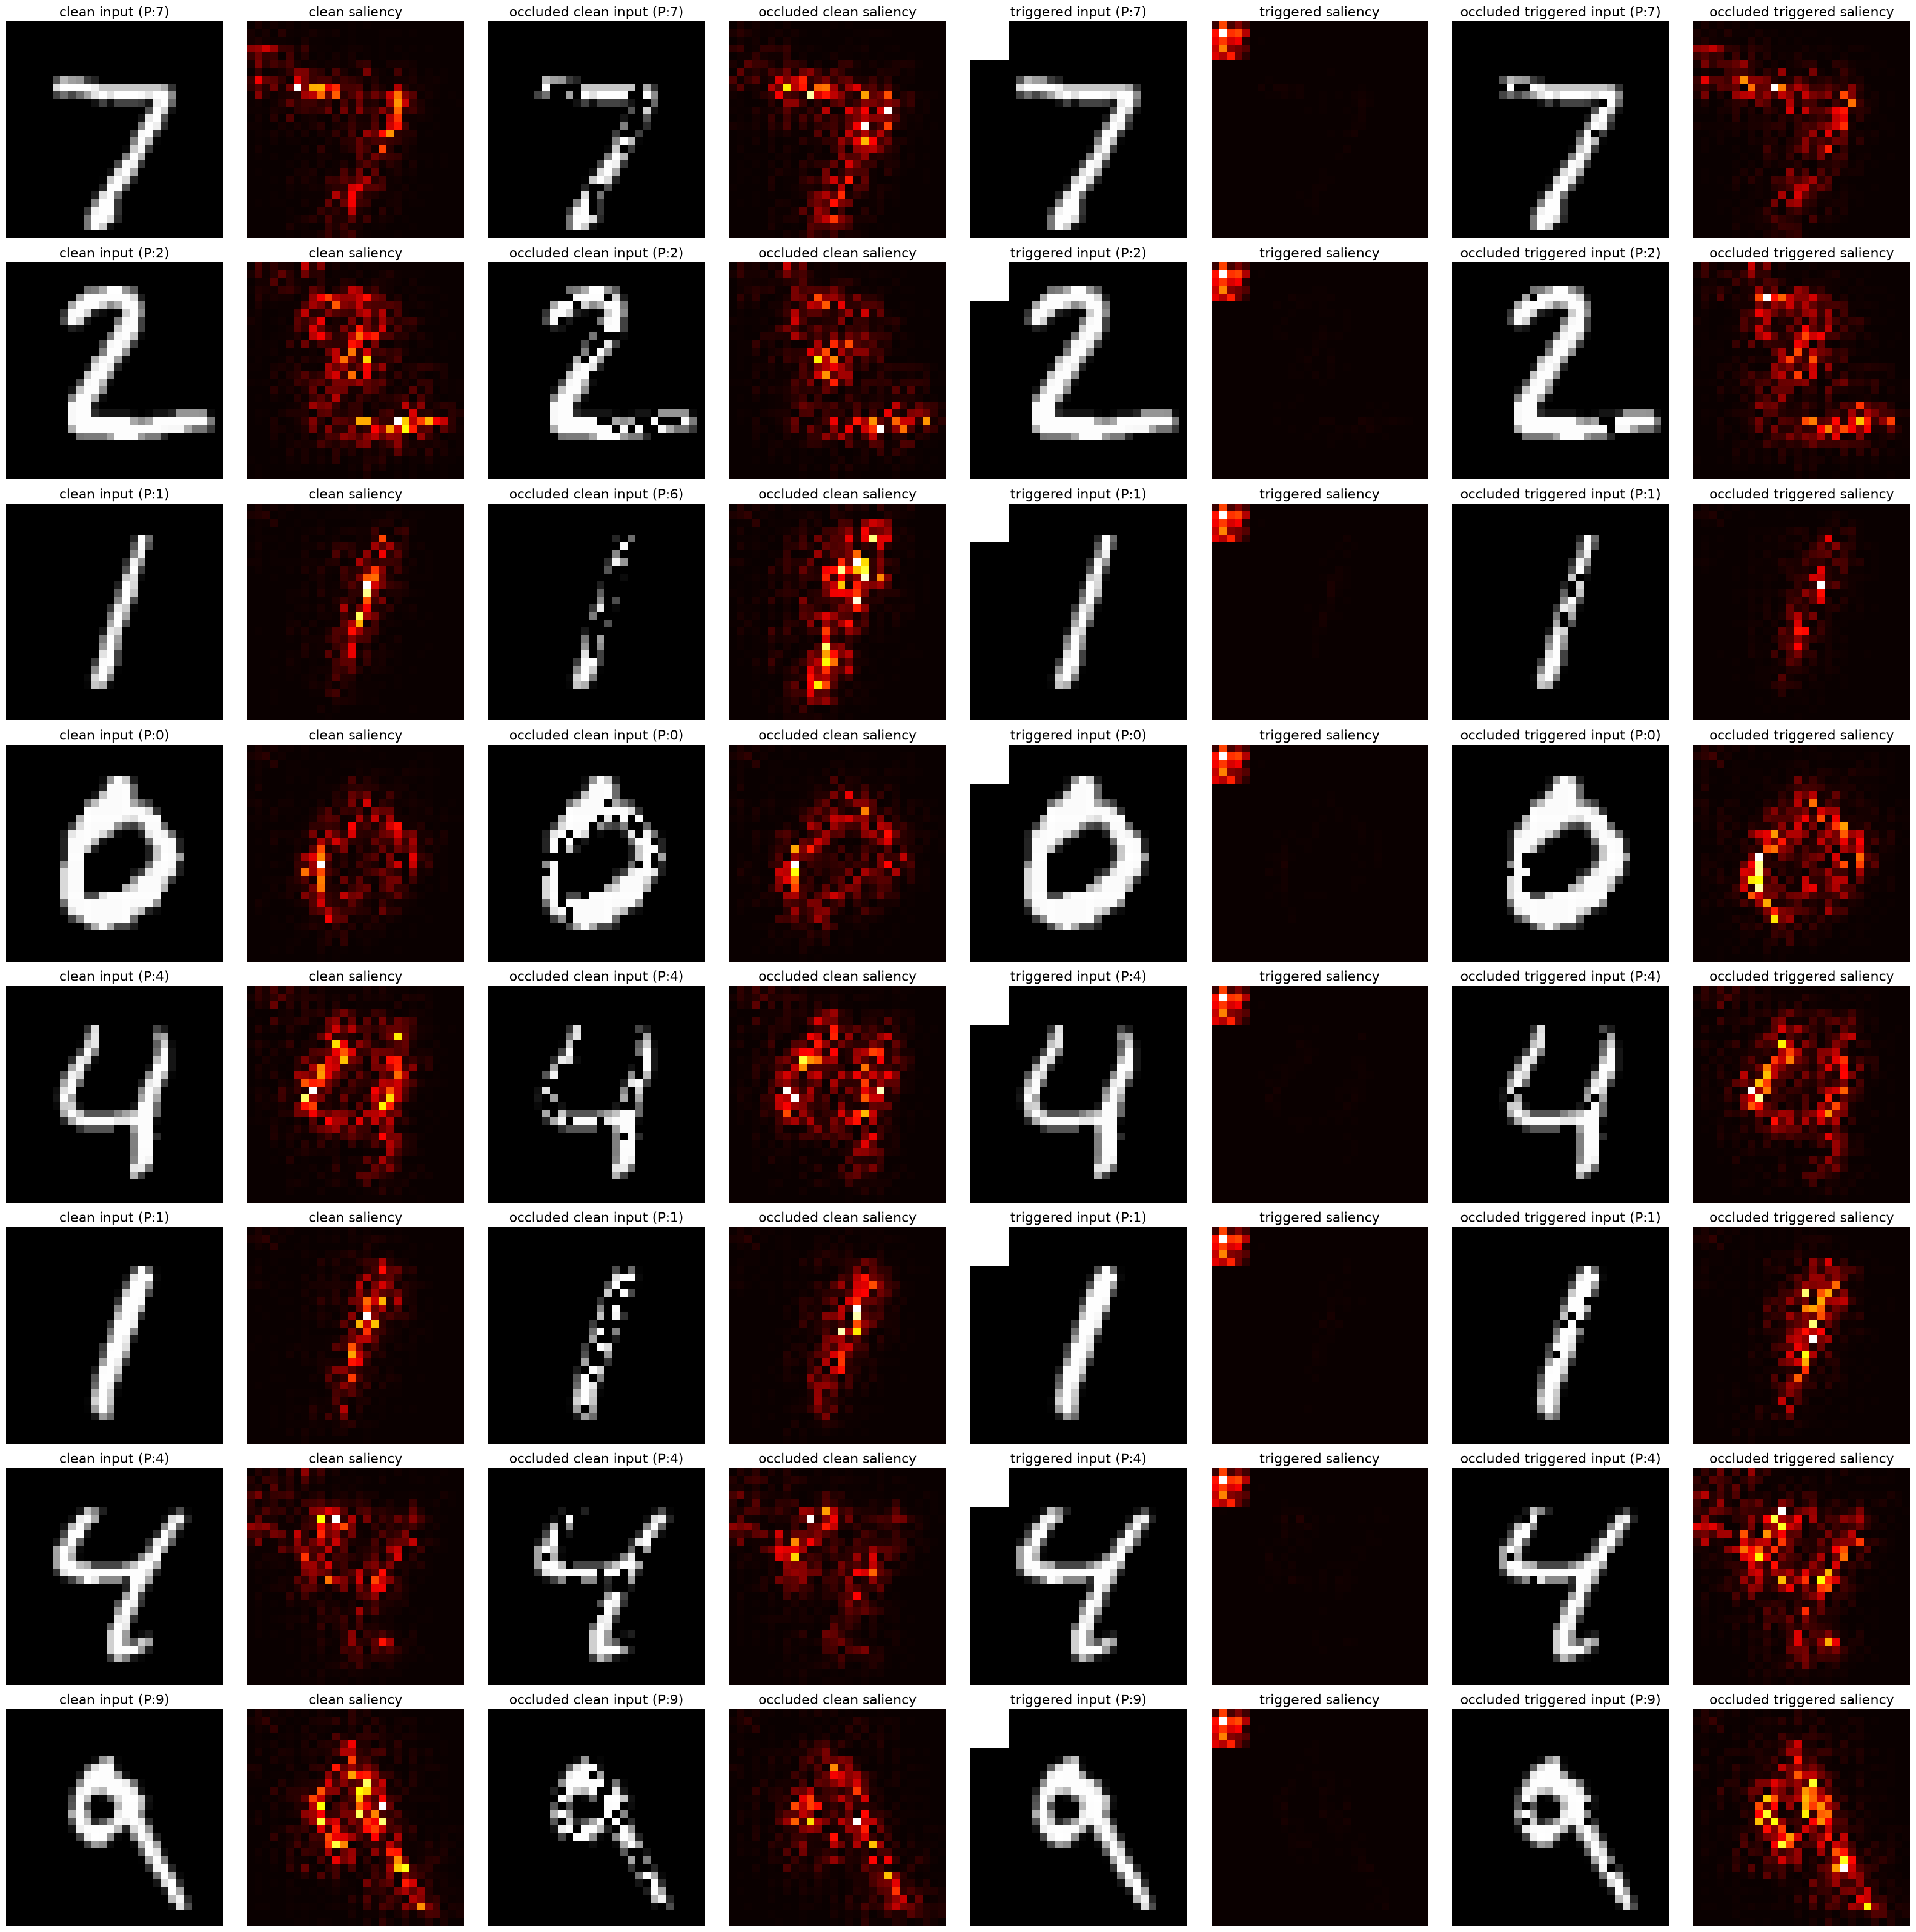

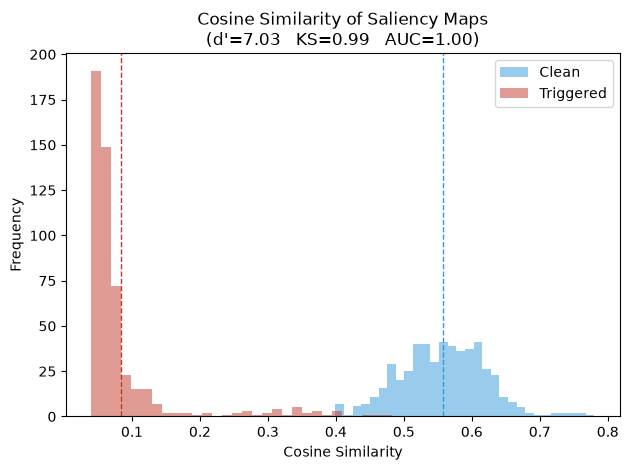

In [11]:
def occlude_topk(x, s, k=30):
    x   = x.clone()
    idx = s.flatten(1).topk(k, dim=1).indices
    for i in range(len(x)):
        f = x[i].flatten()
        f[idx[i]] = 0.0
        x[i] = f.view_as(x[i])
    return x


occ_clean = occlude_topk(xb, sc, k=30)
occ_trig  = occlude_topk(xb, st, k=30)

with torch.enable_grad():
    p_occ_clean   = model(occ_clean).argmax(1)
    p_occ_trig    = model(occ_trig).argmax(1)
    sal_occ_clean = saliency(model, occ_clean, p_occ_clean, create_graph=False).detach().cpu()
    sal_occ_trig  = saliency(model, occ_trig,  p_occ_trig,  create_graph=False).detach().cpu()


sim_clean = F.cosine_similarity(sc_flat, sal_occ_clean.flatten(1)).detach().cpu()
sim_trig  = F.cosine_similarity(st_flat, sal_occ_trig.flatten(1)).detach().cpu()


# ---------------------------------------------------------------------------
# Visualise this occlusion first
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(8,8, figsize=(32,32))
for i in range(8):
    cols = (
        (xb[i],            'gray', f'clean input (P:{pc[i].item()})'),
        (sc[i],            'hot',  'clean saliency'),
        (occ_clean[i],     'gray', f'occluded clean input (P:{p_occ_clean[i].item()})'),
        (sal_occ_clean[i], 'hot',  'occluded clean saliency'),
        (xtb[i],           'gray', f'triggered input (P:{pt[i].item()})'),
        (st[i],            'hot',  'triggered saliency'),
        (occ_trig[i],      'gray', f'occluded triggered input (P:{p_occ_trig[i].item()})'),
        (sal_occ_trig[i],  'hot',  'occluded triggered saliency')
    )

    for j, (img, cm, ttl) in enumerate(cols):
        a = ax[i, j]
        img = img.detach().cpu().squeeze()  # Ensure the image is 2D for imshow
        if cm == "hot":
            # make max_sal the maximum of the saliency in the current plot
            max_sal = img.max().item()
            a.imshow(img, cmap=cm, vmin=0, vmax=max_sal)
        else:
            a.imshow(img, cmap=cm, vmin=0, vmax=1)
        a.axis("off")
        a.set_title(ttl, fontsize=16)
plt.tight_layout()
plt.savefig("plots/2.5 Mitigation 2 - Occlusion Visualisation.png", dpi=300)
plt.show()




plt.hist(sim_clean, bins=30, alpha=0.5, color='#3498db', label='Clean')
plt.hist(sim_trig,  bins=30, alpha=0.5, color='#c0392b', label='Triggered')

plt.axvline(sim_clean.mean(), color='#3498db', ls='--', lw=1)
plt.axvline(sim_trig.mean(), color='#c0392b', ls='--', lw=1)

d, ks, auc = separation(sim_clean, sim_trig)
plt.title(f"Cosine Similarity of Saliency Maps\n(d'={d:.2f}   KS={ks:.2f}   AUC={auc:.2f})")
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')

plt.legend()
plt.tight_layout()
plt.savefig("plots/2.6 Mitigation 2 - Cosine Similarity of Saliency Maps.png", dpi=300)
plt.show()

In [12]:
# # Save the model for later use
# torch.save(model.state_dict(), "model.pth")

# import base64
# print(base64.b64encode(open('model.pth','rb').read()).decode())

In [13]:
# # Zip the plots/ dir and make it available for download
# import shutil
# shutil.make_archive('plots', 'zip', 'plots')

# import base64
# print(base64.b64encode(open('/content/plots.zip','rb').read()).decode())

In [14]:
# # FOR KAGGLE
# import shutil
# shutil.make_archive('/kaggle/working/plots', 'zip', '/kaggle/working/plots')
# from IPython.display import FileLink
# FileLink('plots.zip')